# TP0 - Introduction  (24/02/2025)

## NLTK official documentation

https://www.nltk.org/_modules/

## Labs: Introduction


Homeworks have to be done using jupyter notebooks. Your work should be submitted as a single `.ipynb` (notebook) file, including your code, results and explanatory comments.

Grading of submissions will be based on :
  * Correctness of results
  * Textual description and comments
  * Code Quality

Two options to work with notebooks :
  * Local Python installation (e.g., Anaconda/Vitualenv + JupyterLab/Notebook)
  * Google Colab : notebook hosted by Google


Contact the TAs if you tried and still need help setting things up properly.

## Tools

`Python 3+`

### Libraries
- NLTK
- Numpy
- Pandas
- Pytorch
- Matplotlib

and more if needed!


In [ ]:
import numpy, pandas, matplotlib, nltk

## Tutorial

To complete the exercises, you will have to work with textual data. In this tutorial, we show how to load textual data from file system as well as using libraries for automatically loading data. After loading text data, we pre-process the data for text analysis.  
- Text data is often unstructured and messy, and may contain anomalies such as spelling errors, special characters, and stop words that may lead to inaccurate analysis.
- Pre-processing techniques, such as text **cleaning**, **tokenization**, **stemming** or **lemmatization**, and **stop-word removal**, help to address these issues and ensure that the text is in a suitable format for further analysis.
- Effective pre-processing is essential to obtain meaningful insights and accurate results from text analysis, such as sentiment analysis or topic modeling.

### Loading Data



While working with Google colab, data needs to be uploaded each time you run a session. Use the `Folder` option on left, followed by `Upload to session storage` to upload files.

It is also possible to store and pull data on Google drive and access it using the following code snippet :

```python
from google.colab import drive
drive.mount('/content/drive')
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### File I/O

In [ ]:
import os
import tarfile

In [ ]:
# modify based on your path

path_to_file = os.path.join("/content/drive/MyDrive/nasa", "nasa.tar.gz")  # Updated path
path_to_extract = os.path.join("nasa")

with tarfile.open(path_to_file, 'r:gz') as tar:
    tar.extractall(path_to_extract)


In [ ]:
root_docs_path = os.path.join("nasa")

# find all files that ends with .txt in the given directory and store them in a list
documents = [file for file in os.listdir(root_docs_path) if file.endswith('txt')]

# number of documents to consider, e.g., num_docs = 15
# documents = documents[:num_docs]

# map documents to indices
# make a dictionary where keys are document names and values are their indices
doc2id = documents
id2doc = {doc:idx for idx, doc in enumerate(doc2id)}
id2doc

{'eos00395.txt': 0,
 'eos06695.txt': 1,
 'inf12795.txt': 2,
 'ins16495.txt': 3,
 'str07995.txt': 4,
 'emt11895.txt': 5,
 'inf21595.txt': 6,
 'inf19695.txt': 7,
 'ins07495.txt': 8,
 'eos16095.txt': 9,
 'emt04995.txt': 10,
 'emt01995.txt': 11,
 'emt10495.txt': 12,
 'str10895.txt': 13,
 'ins05895.txt': 14,
 'mip18495.txt': 15,
 'emt21795.txt': 16,
 'sbr18995.txt': 17,
 'mip00195.txt': 18,
 'ins14595.txt': 19,
 'sbr16395.txt': 20,
 'inf17395.txt': 21,
 'emt20895.txt': 22,
 'eos19595.txt': 23,
 'ins20795.txt': 24,
 'ins18795.txt': 25,
 'sbr01495.txt': 26,
 'mip14895.txt': 27,
 'eos06795.txt': 28,
 'mip00595.txt': 29,
 'mat17295.txt': 30,
 'eos19895.txt': 31,
 'inf02895.txt': 32,
 'emt04395.txt': 33,
 'eos20195.txt': 34,
 'emt04495.txt': 35,
 'eos21295.txt': 36,
 'emt13495.txt': 37,
 'emt10695.txt': 38,
 'eos03995.txt': 39,
 'mip01195.txt': 40,
 'mip15495.txt': 41,
 'inf11595.txt': 42,
 'ins04095.txt': 43,
 'mat02395.txt': 44,
 'eos03695.txt': 45,
 'eos07195.txt': 46,
 'sbr17895.txt': 47,
 '

In [ ]:
print("total documents:", len(documents))

# acess the id of a document as id2doc["filename"]
print(id2doc['ins09595.txt'])

# access the i-th document as doc2id[i]
print(doc2id[5])

total documents: 141
91
emt11895.txt


In [ ]:
# store the raw text data in a list
# f.readlines(): each line in the file is a list item

docs_text_raw = [None]*len(documents)

for num_file, file in enumerate(documents):
    with open(os.path.join(root_docs_path, file), mode='r', encoding='windows-1252') as f:
        docs_text_raw[num_file] = f.readlines()

In [ ]:
# emt01995.txt
docs_text_raw[0]

[' \n',
 '\n',
 'Product Design-Life Estimation\n',
 '\n',
 'An automated computerized tool system to estimate product design-life has\n',
 'been developed by a consortium comprised of industry, university, and\n',
 'government. The HiRel (hybrid automated reliability predictor, HARP,\n',
 'integrated reliability) tool system for reliability/ availability estimation\n',
 "offers a toolbox of integrated programs that can be used with HiRel's\n",
 "graphics user interface to customize the user's application in a workstation\n",
 'or non-workstation environment.\n',
 '\n',
 'Potential Commercial Uses\n',
 '\n',
 '   * Automotive systems\n',
 '        o Engine controllers, ABS, powertrain systems\n',
 '   * Aircraft/spacecraft/submarine systems\n',
 '        o Flight/attitude/engine control systems\n',
 '   * Military avionics\n',
 '   * Railroad switching systems\n',
 '   * Telecommunications\n',
 '   * Chemical processing control/monitoring systems\n',
 '   * Nuclear power control system

### Text Pre-Processing

In [ ]:
def clean_raw_text(docs):

    punctuations=r'''!()-[]{};:'"\,<>./?@#$%^&*_~'''
    digits = '0123456789'

    for doc_num, doc in enumerate(docs):
        # doc is a list of sentences
        for sent_num, sent in enumerate(doc):
            # lowercase
            sent = sent.lower()

            # removing the punctuations and numbers
            sent = "".join([char for char in sent if char not in punctuations + digits])

            docs[doc_num][sent_num] = sent

    return docs

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
stop_words = set(stopwords.words('english'))

def tokenize_docs(docs):

    docs = clean_raw_text(docs)
    docs_tokenized = []

    for doc_num, doc in enumerate(docs):

        docs_tokenized.append([nltk.word_tokenize(line) for line in doc])

    return docs_tokenized

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
docs_text_tokenized = tokenize_docs(docs_text_raw)

In [ ]:
docs_text_tokenized[0]

In [ ]:
def flatten(doc):
    # doc is a list of lists
    # convert into a single flat list (collapse all sentences of the doc into one)
    # check if sentences are empty because of preprocessing/tokenization
    return [word for sentence in doc for word in sentence if len(sentence) > 0]

In [ ]:
docs_text_tokenized = [flatten(doc) for doc in docs_text_tokenized]

In [ ]:
docs_text_tokenized[0]

### Remove Stop Words

In [ ]:
print([len(doc) for doc in docs_text_tokenized], end=' ')

[481, 270, 422, 457, 562, 369, 707, 426, 452, 235, 315, 578, 643, 440, 396, 401, 572, 558, 601, 498, 504, 511, 427, 401, 483, 477, 571, 473, 392, 342, 532, 559, 617, 497, 440, 353, 315, 344, 605, 382, 465, 467, 744, 331, 378, 343, 302, 507, 366, 515, 458, 465, 460, 359, 429, 529, 585, 567, 493, 391, 467, 329, 335, 572, 429, 446, 456, 448, 605, 408, 393, 413, 426, 424, 715, 283, 522, 511, 511, 406, 558, 477, 448, 408, 381, 366, 222, 425, 376, 585, 559, 378, 505, 453, 552, 529, 536, 253, 368, 577, 517, 560, 504, 328, 440, 448, 447, 544, 407, 421, 216, 499, 540, 306, 409, 430, 453, 462, 515, 472, 575, 347, 578, 377, 363, 535, 497, 402, 414, 500, 326, 407, 353, 336, 449, 667, 259, 468, 436, 402, 404] 

In [ ]:
docs_text_tokenized = [[w for w in doc if w not in stop_words] for doc in docs_text_tokenized]

In [ ]:
docs_text_tokenized

In [ ]:
print([len(doc) for doc in docs_text_tokenized], end=' ')

[316, 167, 285, 301, 370, 250, 447, 287, 292, 161, 206, 350, 411, 300, 249, 261, 361, 384, 364, 300, 356, 308, 311, 262, 289, 322, 388, 294, 276, 216, 383, 356, 400, 318, 275, 227, 211, 224, 398, 256, 310, 307, 471, 227, 270, 233, 191, 346, 223, 369, 283, 283, 333, 224, 288, 363, 419, 357, 322, 234, 303, 210, 220, 371, 252, 272, 299, 307, 387, 256, 231, 269, 281, 289, 472, 192, 355, 349, 327, 255, 351, 321, 298, 273, 228, 215, 133, 269, 231, 390, 371, 240, 339, 301, 351, 372, 363, 152, 239, 368, 373, 355, 317, 233, 296, 273, 269, 355, 280, 274, 142, 329, 353, 214, 271, 291, 295, 305, 311, 314, 377, 245, 362, 250, 217, 330, 356, 277, 287, 355, 204, 267, 234, 236, 291, 485, 179, 284, 285, 272, 261] 

### Stemming

In [ ]:
from nltk.stem import PorterStemmer

In [ ]:
def stem(docs):

    ps = PorterStemmer()
    docs_stemmed = []

    for doc in docs:
        # stemmer takes a string as input
        docs_stemmed.append([ps.stem(word) for word in doc])

    return docs_stemmed

In [ ]:
docs_text_stemmed = stem(docs_text_tokenized)

In [ ]:
docs_text_stemmed[1]

['molecular',
 'flow',
 'imag',
 'rayleigh',
 'scatter',
 'possibl',
 'obtain',
 'planar',
 'rayleigh',
 'scatter',
 'data',
 'mach',
 'flow',
 'field',
 'due',
 'rapid',
 'technolog',
 'advanc',
 'high',
 'power',
 'puls',
 'excim',
 'laser',
 'gate',
 'singl',
 'intensifi',
 'chargecoupl',
 'devic',
 'ccd',
 'camera',
 'fast',
 'frame',
 'grabber',
 'short',
 'laser',
 'puls',
 'nanosecond',
 'use',
 'flow',
 'essenti',
 'frozen',
 'data',
 'acquisit',
 'cycl',
 'allow',
 'snapshot',
 'flow',
 'field',
 'taken',
 'snapshot',
 'reveal',
 'extent',
 'unsteadi',
 'flow',
 'field',
 'also',
 'possibl',
 'averag',
 'snapshot',
 'obtain',
 'mean',
 'quantit',
 'densiti',
 'map',
 'flow',
 'field',
 'benefit',
 'multipoint',
 'nonintrus',
 'flow',
 'diagnost',
 'techniqu',
 'high',
 'resolut',
 'requir',
 'seed',
 'flow',
 'signal',
 'linearli',
 'depend',
 'densiti',
 'molecul',
 'flow',
 'essenti',
 'frozen',
 'laser',
 'shot',
 'potenti',
 'commerci',
 'use',
 'system',
 'use',
 'visual'

### Simple querying

In [ ]:
# ask the user to input a query, e.g.:process
query = input("Enter your query: ")

# count the occurrences of the query in the stemmed document
occurrences = docs_text_stemmed[0].count(query)

# print the number of occurrences found
if occurrences > 0:
    print(f"The query '{query}' is present {occurrences} times in the document.")
else:
    print(f"The query '{query}' is not present in the document.")


Enter your query: i love bananas
The query 'i love bananas' is not present in the document.


### Tag Cloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

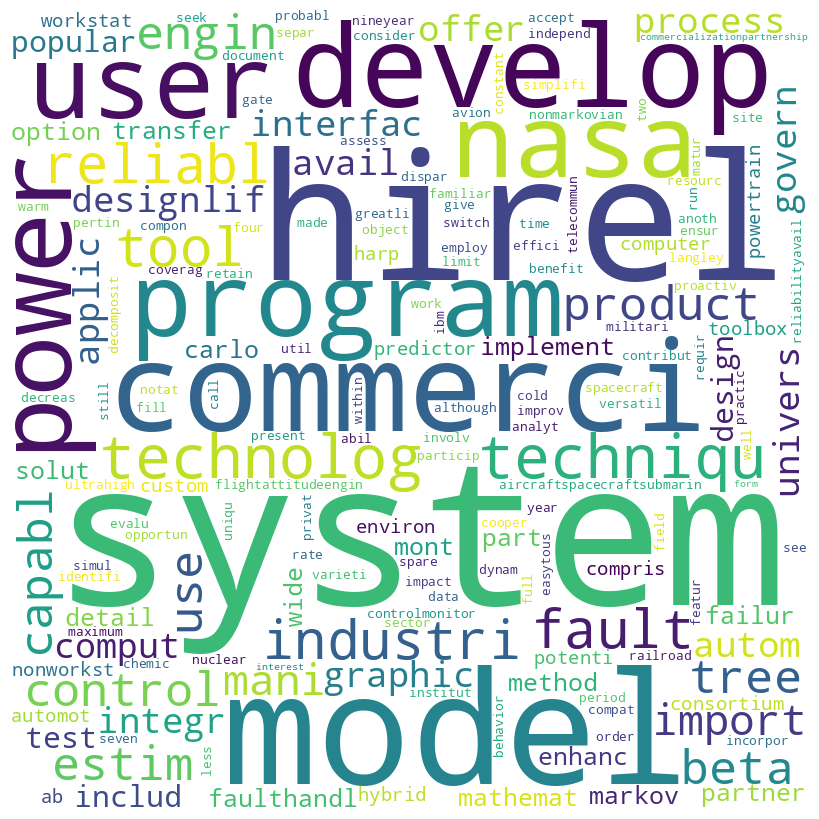

In [ ]:
# join all the words into a single string separated by spaces
text = " ".join(docs_text_stemmed[0])

# create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color="white", min_font_size=10).generate(text)

# display the tag cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

# show the tag cloud
plt.show()

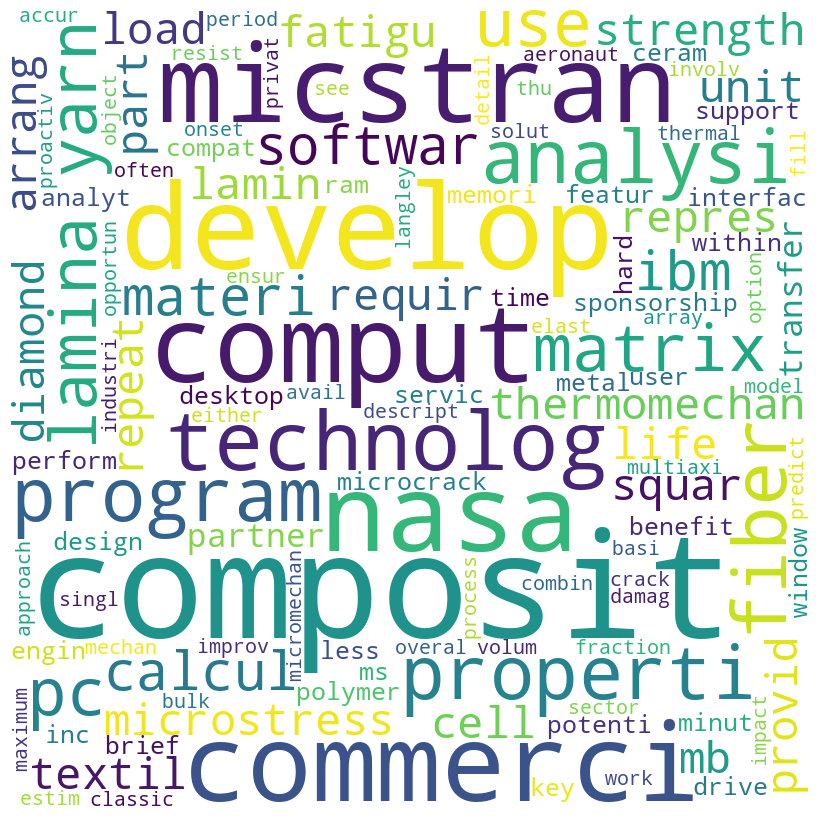

In [ ]:
# join all the words into a single string separated by spaces
text = " ".join(docs_text_stemmed[10])

# create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color="white", min_font_size=10).generate(text)

# display the tag cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

# show the tag cloud
plt.show()

### Fuzzy text search

You can search for words similar to a specific word in the document using the fuzzywuzzy library.

The result of the fuzzy text search will be a list of tuples containing the closest matches to the input word, along with a score indicating how closely each match corresponds to the input word.

For example, if the input word is "model", and the threshold is set to 70, then the results will include any words that have a partial ratio score of at least 70. The partial ratio score is a measure of how well the two strings match, taking into account differences in length, character order, and character matching.

from fuzzywuzzy import fuzz, process

In [ ]:
# pip install fuzzywuzzy

In [ ]:
from fuzzywuzzy import fuzz, process
# example of fuzzy text search
word = "model"
choices = [item for sublist in docs_text_stemmed for item in sublist]
ratio_threshold = 70

results = process.extract(word, choices, scorer=fuzz.partial_ratio)
matches = [(r[0], r[1]) for r in results if r[1] >= ratio_threshold]
print(f"The word '{word}' has the following fuzzy matches: {matches}")

/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


The word 'model' has the following fuzzy matches: [('model', 100), ('model', 100), ('model', 100), ('model', 100), ('model', 100)]


### Boolean text search

You can search for words that satisfy a certain Boolean condition, such as "AND", "OR", and "NOT", in the document using regular expressions. The output of the code is a string that indicates which words in the text matched the search criteria, by printing the list of matched words enclosed in square brackets.
For example, if you want to find all occurrences of "house" or "nasa" in the document, you can use the following code:

In [ ]:
import re

In [ ]:
# example of boolean text search
regex = re.compile(r'\b(house|nasa)\b')
text = ' '.join(docs_text_stemmed[1])

# convert list to string
matches = regex.findall(text)
print(f"The following words matched the search criteria: {matches}")

The following words matched the search criteria: ['nasa', 'nasa', 'nasa', 'nasa']
